In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import scene_generation.core as core_mod
import time
import json

from pathlib import Path
from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size
from collections import Counter
from matplotlib.patches import Patch
from PIL import Image, ImageDraw
from sionna.rt import scene, preview

In [9]:
relative_to_lidar_osm = []

lidar_osm_hag_perc = []
lidar_osm_building_height_perc = []
lidar_osm_height_perc = []
lidar_osm_building_levels_perc = []
lidar_osm_levels_perc = []
lidar_osm_random_fallback_perc = []
overture_height_perc = []
overture_levels_perc = []
overture_random_fallback_perc = []

overall_mean_abs_diff = []
overall_max_abs_diff = []
lidar_outside_explicit_overture_height = []

STATS_FILE = Path("./stats_progress.json")

In [10]:
def save_stats():
    data = {
        "relative_to_lidar_osm": relative_to_lidar_osm,
        "lidar_osm_hag_perc": lidar_osm_hag_perc,
        "lidar_osm_building_height_perc": lidar_osm_building_height_perc,
        "lidar_osm_height_perc": lidar_osm_height_perc,
        "lidar_osm_building_levels_perc": lidar_osm_building_levels_perc,
        "lidar_osm_levels_perc": lidar_osm_levels_perc,
        "lidar_osm_random_fallback_perc": lidar_osm_random_fallback_perc,
        "overture_height_perc": overture_height_perc,
        "overture_levels_perc": overture_levels_perc,
        "overture_random_fallback_perc": overture_random_fallback_perc,
        "overall_mean_abs_diff": overall_mean_abs_diff,
        "overall_max_abs_diff": overall_max_abs_diff,
        "lidar_outside_explicit_overture_height": lidar_outside_explicit_overture_height,
    }
    tmp = STATS_FILE.with_suffix(".tmp")
    STATS_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(tmp, "w") as f:
        json.dump(data, f)
    os.replace(tmp, STATS_FILE)

In [11]:
def load_stats():
    if not STATS_FILE.exists():
        return
    with open(STATS_FILE, "r") as f:
        data = json.load(f)
    relative_to_lidar_osm.extend(data.get("relative_to_lidar_osm", []))
    lidar_osm_hag_perc.extend(data.get("lidar_osm_hag_perc", []))
    lidar_osm_building_height_perc.extend(data.get("lidar_osm_building_height_perc", []))
    lidar_osm_height_perc.extend(data.get("lidar_osm_height_perc", []))
    lidar_osm_building_levels_perc.extend(data.get("lidar_osm_building_levels_perc", []))
    lidar_osm_levels_perc.extend(data.get("lidar_osm_levels_perc", []))
    lidar_osm_random_fallback_perc.extend(data.get("lidar_osm_random_fallback_perc", []))
    overture_height_perc.extend(data.get("overture_height_perc", []))
    overture_levels_perc.extend(data.get("overture_levels_perc", []))
    overture_random_fallback_perc.extend(data.get("overture_random_fallback_perc", []))
    overall_mean_abs_diff.extend(data.get("overall_mean_abs_diff", []))
    overall_max_abs_diff.extend(data.get("overall_max_abs_diff", []))
    lidar_outside_explicit_overture_height.extend(data.get("lidar_outside_explicit_overture_height", []))


In [12]:
load_stats()

In [ ]:
def run_analysis(CENTER_LON, CENTER_LAT, placename):    

    SCENE_WIDTH  = 500   # east–west extent, metres
    SCENE_HEIGHT = 500   # north–south extent, metres

    DATA_DIR_LIDAR_OSM = f"./scenes/{placename}_lidar_osm"
    DATA_DIR_OVERTURE = f"./scenes/{placename}_overture"

    OSM_SERVER = "http://192.168.0.110:3452/api/interpreter"
    # public server: "https://overpass-api.de/api/interpreter"

    for out_dir in (DATA_DIR_LIDAR_OSM, DATA_DIR_OVERTURE):
        os.makedirs(out_dir, exist_ok=True)
        print(f"Output directory: {os.path.abspath(out_dir)}")

    def summarize_height_sources(mode, height_sources):
        """Summarize counts and percentages of buildings by selected height source."""
        total_buildings = sum(height_sources.values())
        rows = []

        for source, building_count in height_sources.most_common():
            building_percentage = (
                (building_count / total_buildings) * 100 if total_buildings else 0.0
            )
            rows.append(
                {
                    "mode": mode,
                    "height_source": source,
                    "building_count": building_count,
                    "building_percentage": f"{building_percentage:.2f}%",
                }
            )

        return pd.DataFrame(
            rows,
            columns=["mode", "height_source", "building_count", "building_percentage"],
        )

    def iter_polygons(geometry):
        """Yield polygon parts from a Shapely Polygon or MultiPolygon."""
        if geometry is None or geometry.is_empty:
            return

        if geometry.geom_type == "Polygon":
            yield geometry
        elif geometry.geom_type == "MultiPolygon":
            yield from geometry.geoms

    def rasterize_height_source_mask(records, height_source, shape, ground_bounds):
        """Rasterize footprints for one height source onto a building-map grid."""
        min_x, _, _, max_y = ground_bounds
        mask_image = Image.new("1", (shape[1], shape[0]), 0)
        draw = ImageDraw.Draw(mask_image)

        for record in records:
            if record["height_source"] != height_source:
                continue

            for polygon in iter_polygons(record["footprint"]):
                pixel_coords = [(x - min_x, max_y - y) for x, y in polygon.exterior.coords]
                draw.polygon(pixel_coords, outline=1, fill=1)

        return np.array(mask_image, dtype=bool)

    def generate_scene(mode, out_dir, *, track_height_sources=False):
        """Generate the scene and optionally count selected height sources."""
        scene_polygon = rect_from_point_and_size(
        CENTER_LON, CENTER_LAT, "center", SCENE_WIDTH, SCENE_HEIGHT
        )

        height_sources = []
        height_source_records = []
        original_resolve = core_mod.resolve_building_height

        def logging_resolve_building_height(*args, **kwargs):
            kwargs = dict(kwargs)
            kwargs["return_source"] = True
            height, metadata = original_resolve(*args, **kwargs)
            source = metadata.get("source", "unknown")
            footprint = args[1] if len(args) > 1 else kwargs.get("building_polygon")
            height_sources.append(source)
            height_source_records.append(
                {
                    "mode": mode,
                    "height_source": source,
                    "height_m": height,
                    "footprint": footprint,
                }
            )
            return height

        if track_height_sources:
            core_mod.resolve_building_height = logging_resolve_building_height

        try:
            scene = Scene()
            building_height_map = scene(
                points=scene_polygon,
                data_dir=out_dir,
                osm_server_addr=OSM_SERVER,
                hag_tiff_path=None,  # None lets lidar-osm create/reuse out_dir/test_hag.tif
                ground_material_type="mat-itu_wet_ground",
                rooftop_material_type="mat-itu_metal",
                wall_material_type="mat-itu_concrete",
                generate_building_map=True,
                building_height_mode=mode,
                # lidar_terrain=False,
                # dem_terrain=False,
            )
            ground_bounds = scene._ground_polygon_envelope_UTM.bounds
        finally:
            if track_height_sources:
                core_mod.resolve_building_height = original_resolve

        return building_height_map, Counter(height_sources), height_source_records, ground_bounds

    scene_generation_runtimes = []

    start_time = time.perf_counter()
    lidar_height_map, lidar_height_sources, lidar_height_source_records, lidar_ground_bounds = generate_scene(
        "lidar-osm", DATA_DIR_LIDAR_OSM, track_height_sources=True
    )
    scene_generation_runtimes.append(
        {"mode": "lidar-osm", "runtime_seconds": time.perf_counter() - start_time}
    )

    start_time = time.perf_counter()
    overture_height_map, overture_height_sources, overture_height_source_records, overture_ground_bounds = generate_scene(
        "overture", DATA_DIR_OVERTURE, track_height_sources=True
    )
    scene_generation_runtimes.append(
        {"mode": "overture", "runtime_seconds": time.perf_counter() - start_time}
    )

    print("Scene generation complete!")
    scene_generation_runtime_summary = pd.DataFrame(scene_generation_runtimes)
    lidar_runtime_seconds = scene_generation_runtime_summary.loc[
        scene_generation_runtime_summary["mode"] == "lidar-osm",
        "runtime_seconds",
    ].iloc[0]
    scene_generation_runtime_summary["runtime_seconds"] = scene_generation_runtime_summary[
        "runtime_seconds"
    ].round(3)
    scene_generation_runtime_summary["relative_to_lidar_osm"] = (
        scene_generation_runtime_summary["runtime_seconds"] / lidar_runtime_seconds
    ).round(2)

    relative_to_lidar_osm.append(scene_generation_runtime_summary["relative_to_lidar_osm"].iloc[1])
    save_stats()

    
    display(scene_generation_runtime_summary)

    height_source_summary = pd.concat(
        [
            summarize_height_sources("lidar-osm", lidar_height_sources),
            
            summarize_height_sources("overture", overture_height_sources),
        ],
        ignore_index=True,
    )
    display(height_source_summary)

    total_lidar = sum(lidar_height_sources.values())
    lidar_source_percents = {
        "hag": lidar_osm_hag_perc,
        "osm:building:height": lidar_osm_building_height_perc,
        "osm:height": lidar_osm_height_perc,
        "osm:building:levels": lidar_osm_building_levels_perc,
        "osm:levels": lidar_osm_levels_perc,
        "fallback:random": lidar_osm_random_fallback_perc,
    }
    for source, target_list in lidar_source_percents.items():
        perc = (
            100.0 * lidar_height_sources.get(source, 0) / total_lidar
            if total_lidar
            else 0.0
        )
        target_list.append(perc)

    save_stats()

    total_overture = sum(overture_height_sources.values())
    overture_source_percents = {
        "overture:height": overture_height_perc,
        "overture:levels": overture_levels_perc,
        "fallback:random": overture_random_fallback_perc,
    }
    for source, target_list in overture_source_percents.items():
        perc = (
            100.0 * overture_height_sources.get(source, 0) / total_overture
            if total_overture
            else 0.0
        )
        target_list.append(perc)

    save_stats()

    # Compare final building-height maps from the two modes.
    lidar_map = np.load(Path(DATA_DIR_LIDAR_OSM) / "2D_Building_Height_Map.npy")
    overture_map = np.load(Path(DATA_DIR_OVERTURE) / "2D_Building_Height_Map.npy")

    diff = lidar_map.astype(float) - overture_map.astype(float)
    building_mask = (lidar_map > 0) | (overture_map > 0)
    mean_abs_diff = np.mean(np.abs(diff[building_mask])) if building_mask.any() else 0.0
    max_abs_diff = np.max(np.abs(diff)) if diff.size else 0.0
    lidar_hag_mask = rasterize_height_source_mask(
        lidar_height_source_records,
        "hag",
        lidar_map.shape,
        lidar_ground_bounds,
    )
    overture_explicit_height_mask = rasterize_height_source_mask(
        overture_height_source_records,
        "overture:height",
        lidar_map.shape,
        overture_ground_bounds,
    )
    building_pixel_count = int(np.count_nonzero(building_mask))
    lidar_hag_not_overture_explicit_height_pixels = int(
            np.count_nonzero(lidar_hag_mask & ~overture_explicit_height_mask)
    )
    lidar_hag_not_overture_explicit_height_percent = (
            100.0
            * lidar_hag_not_overture_explicit_height_pixels
            / building_pixel_count
            if building_pixel_count
            else 0.0
    )
    overall_mean_abs_diff.append(float(mean_abs_diff))
    overall_max_abs_diff.append(float(max_abs_diff))
    lidar_outside_explicit_overture_height.append(lidar_hag_not_overture_explicit_height_percent)
    save_stats()

    comparison = pd.DataFrame(
        [
            ("same raster", np.array_equal(lidar_map, overture_map)),
            ("mean abs diff on building pixels (m)", round(float(mean_abs_diff), 3)),
            ("max abs diff (m)", round(float(max_abs_diff), 3)),
            (
                "LiDAR HAG pixels outside Overture explicit height (%)",
                round(float(lidar_hag_not_overture_explicit_height_percent), 3),
            ),
        ],
        columns=["check", "value"],
    )
    display(comparison)

    height_vmax = max(float(lidar_map.max()), float(overture_map.max()), 1.0)
    diff_abs_max = max(float(np.max(np.abs(diff))), 1.0) if diff.size else 1.0

    plt.show()

In [14]:
# Scene center (only need to update CENTER_LON, CENTER_LAT, DATA_DIR_LIDAR_OSM, DATA_DIR_OVERTURE and run the rest of the cells to receive full analysis)
# DuPont Circle: -77.043446, 38.909647
# Duke Wilkinson area: -78.940297, 36.002556
# Flatiron Building: -73.9897, 40.7411

'''
21 areas used for initial analysis
areas_of_interest = [
    [-77.043446, 38.909647, "dupont"],
    [-78.940297, 36.002556, "wilkinson"],
    [-73.9897, 40.7411, "flatiron"],
    [-118.40036, 34.07362, "beverlyhills"],
    [-87.5939377, 41.7942008, "hydepark"],
    [-80.237709, 25.777643, "littlehavanamiami"],
    [-75.1896236, 39.9492795, "universitycityphilly"],
    [-95.388992, 29.760427, "houston"],
    [-96.7900708, 32.7849914, "deepellumdallas"],
    [-77.024698, 38.879393, "dcwharf"],
    [-83.3623853, 33.5684599, "buckheadatlanta"],
    [-112.074036, 33.448376, "phoenix"],
    [-82.99611, 42.36028, "indianvillagedetroit"],
    [-122.316456, 47.622942, "capitolhillseattle"],
    [-122.41448, 37.79323, "nobhillsanfrancisco"],
    [-117.142586, 32.730831, "balboaparksandiego"],
    [-93.258133, 44.986656, "minneapolis"],
    [-82.4573, 27.9942, "seminoleheightstampa"],
    [-104.991531, 39.742043, "denver"],
    [-117.396156, 33.953350, "riverside"],
    [-76.6317, 39.3317, "hampdenbaltimore"]
]
'''

# use cities.json (obtained from https://gist.github.com/Miserlou/c5cd8364bf9b2420bb29)
# to parse for U.S. urban areas
with open("cities.json", "r") as f:
    cities = json.load(f)

areas_of_interest = []
for i in range(100):
    areas_of_interest.append([cities[i]["longitude"], cities[i]["latitude"], cities[i]["city"].replace(" ", "_")])
for i in range(len(cities) - 1, len(cities) - 101, -1):
    areas_of_interest.append([cities[i]["longitude"], cities[i]["latitude"], cities[i]["city"].replace(" ", "_")])

for CENTER_LON, CENTER_LAT, placename in areas_of_interest:
    run_analysis(CENTER_LON, CENTER_LAT, placename)

Output directory: /home/rt279/geo2sigmap-fork/research/examples/scenes/New_York_lidar_osm
Output directory: /home/rt279/geo2sigmap-fork/research/examples/scenes/New_York_overture


ConnectTimeout: HTTPSConnectionPool(host='192.168.0.110', port=3452): Max retries exceeded with url: /api/interpreter/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='192.168.0.110', port=3452) at 0x763f4c387a10>, 'Connection to 192.168.0.110 timed out. (connect timeout=180)'))

In [ ]:
print(len(relative_to_lidar_osm), relative_to_lidar_osm)

print(len(lidar_osm_hag_perc), lidar_osm_hag_perc)
print(len(lidar_osm_building_height_perc), lidar_osm_building_height_perc)
print(len(lidar_osm_height_perc), lidar_osm_height_perc)
print(len(lidar_osm_building_levels_perc), lidar_osm_building_levels_perc)
print(len(lidar_osm_levels_perc), lidar_osm_levels_perc)
print(len(lidar_osm_random_fallback_perc), lidar_osm_random_fallback_perc)
print(len(overture_height_perc), overture_height_perc)
print(len(overture_levels_perc), overture_levels_perc)
print(len(overture_random_fallback_perc), overture_random_fallback_perc)

print(len(overall_mean_abs_diff), overall_mean_abs_diff)
print(len(overall_max_abs_diff), overall_max_abs_diff)
print(len(lidar_outside_explicit_overture_height), lidar_outside_explicit_overture_height)

NameError: name 'relative_to_lidar_osm' is not defined

In [ ]:
# function that takes in each stat array and a suitable title, prints the mean and plots the distribution
def print_and_plot_stats(stat_array, title):
    mean = np.mean(stat_array)
    median = np.median(stat_array)
    print(f"Mean of {title}: {mean:.2f}")
    print(f"Median of {title}: {median:.2f}")

    plt.hist(stat_array, bins=20, alpha=0.7)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

Mean of Relative Runtime of Overture vs. LiDAR-OSM: 1.39
Median of Relative Runtime of Overture vs. LiDAR-OSM: 1.34


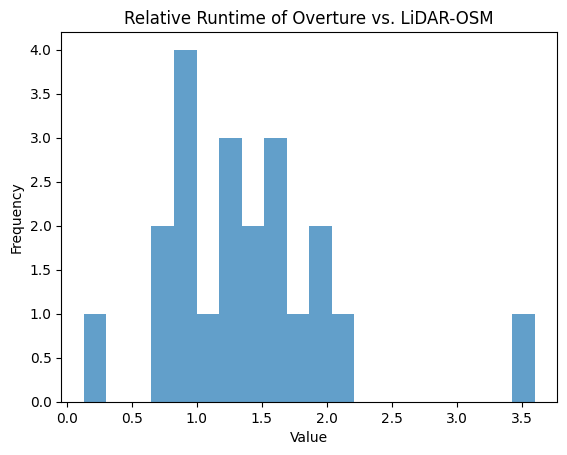

In [ ]:
print_and_plot_stats(relative_to_lidar_osm, "Relative Runtime of Overture vs. LiDAR-OSM")

Mean of Percentage of Building Heights Derived from LiDAR in LiDAR-OSM Mode: 89.00
Median of Percentage of Building Heights Derived from LiDAR in LiDAR-OSM Mode: 99.63


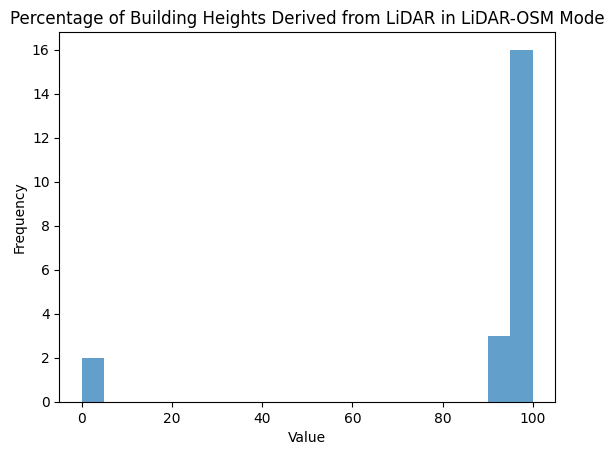

In [ ]:
print_and_plot_stats(lidar_osm_hag_perc, "Percentage of Building Heights Derived from LiDAR in LiDAR-OSM Mode")

Mean of Percentage of Building Heights Derived from OSM Building:Height Tag in LiDAR-OSM Mode: 0.00
Median of Percentage of Building Heights Derived from OSM Building:Height Tag in LiDAR-OSM Mode: 0.00


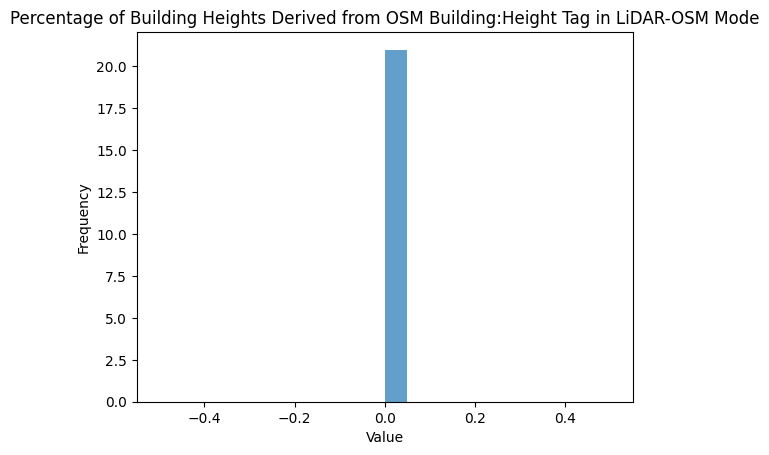

In [ ]:
print_and_plot_stats(lidar_osm_building_height_perc, "Percentage of Building Heights Derived from OSM Building:Height Tag in LiDAR-OSM Mode")

Mean of Percentage of Building Heights Derived from OSM Height Tag in LiDAR-OSM Mode: 5.13
Median of Percentage of Building Heights Derived from OSM Height Tag in LiDAR-OSM Mode: 0.00


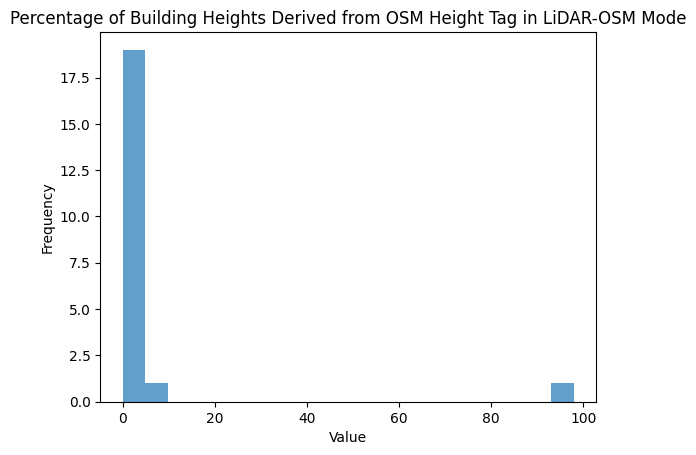

In [ ]:
print_and_plot_stats(lidar_osm_height_perc, "Percentage of Building Heights Derived from OSM Height Tag in LiDAR-OSM Mode")

Mean of Percentage of Building Heights Derived from OSM Building:Levels Tag in LiDAR-OSM Mode: 0.45
Median of Percentage of Building Heights Derived from OSM Building:Levels Tag in LiDAR-OSM Mode: 0.00


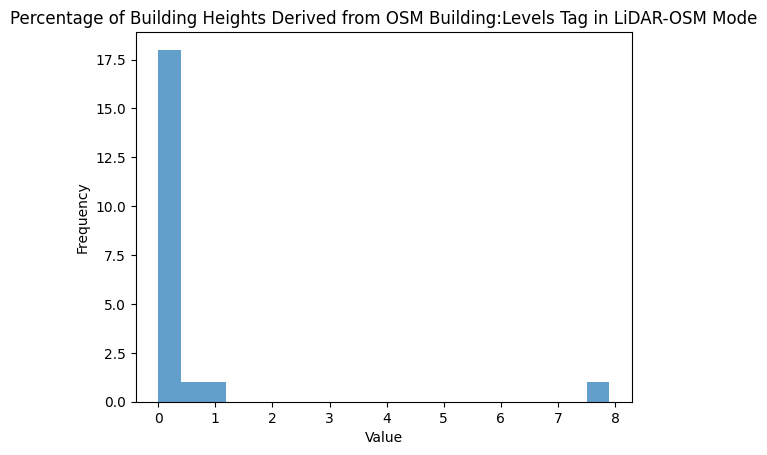

In [ ]:
print_and_plot_stats(lidar_osm_building_levels_perc, "Percentage of Building Heights Derived from OSM Building:Levels Tag in LiDAR-OSM Mode")

Mean of Percentage of Building Heights Derived from OSM Levels Tag in LiDAR-OSM Mode: 0.00
Median of Percentage of Building Heights Derived from OSM Levels Tag in LiDAR-OSM Mode: 0.00


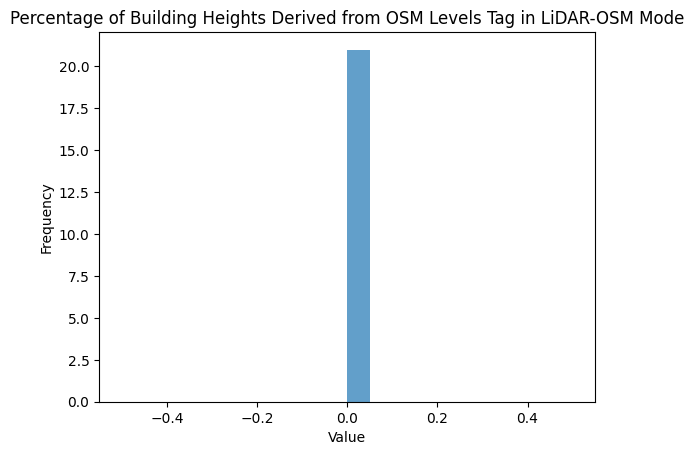

In [ ]:
print_and_plot_stats(lidar_osm_levels_perc, "Percentage of Building Heights Derived from OSM Levels Tag in LiDAR-OSM Mode")

Mean of Percentage of Building Heights Derived from Random Fallback in LiDAR-OSM Mode: 5.42
Median of Percentage of Building Heights Derived from Random Fallback in LiDAR-OSM Mode: 0.00


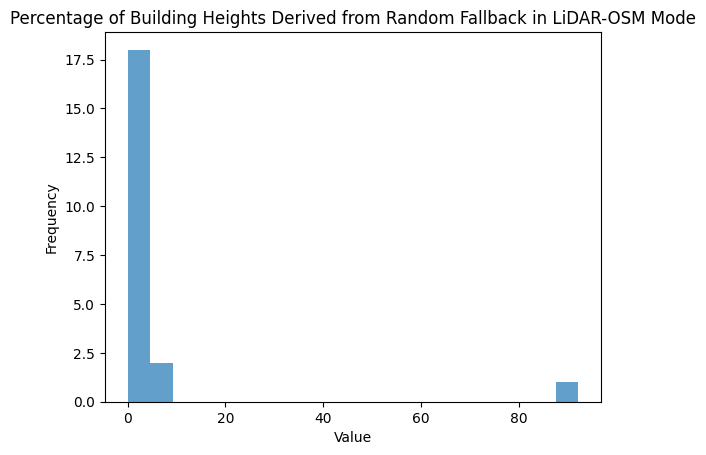

In [ ]:
print_and_plot_stats(lidar_osm_random_fallback_perc, "Percentage of Building Heights Derived from Random Fallback in LiDAR-OSM Mode")

Mean of Percentage of Building Heights Derived from Overture Explicit Height in Overture Mode: 78.26
Median of Percentage of Building Heights Derived from Overture Explicit Height in Overture Mode: 93.19


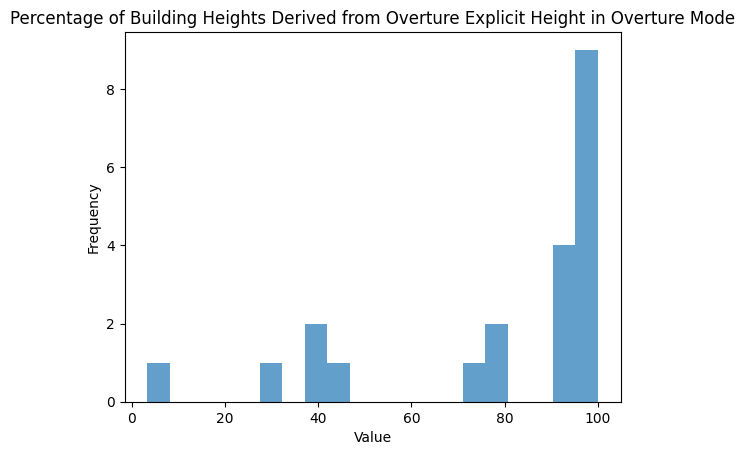

In [ ]:
print_and_plot_stats(overture_height_perc, "Percentage of Building Heights Derived from Overture Explicit Height in Overture Mode")

Mean of Percentage of Building Heights Derived from Overture Levels in Overture Mode: 2.87
Median of Percentage of Building Heights Derived from Overture Levels in Overture Mode: 0.41


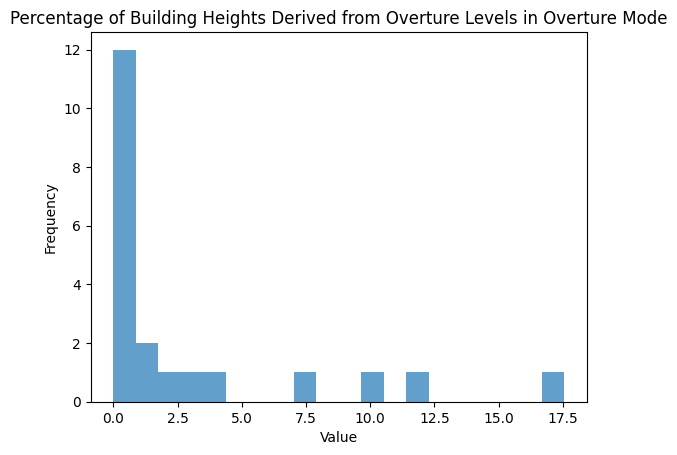

In [ ]:
print_and_plot_stats(overture_levels_perc, "Percentage of Building Heights Derived from Overture Levels in Overture Mode")

Mean of Percentage of Building Heights Derived from Overture Random Fallback in Overture Mode: 18.86
Median of Percentage of Building Heights Derived from Overture Random Fallback in Overture Mode: 6.23


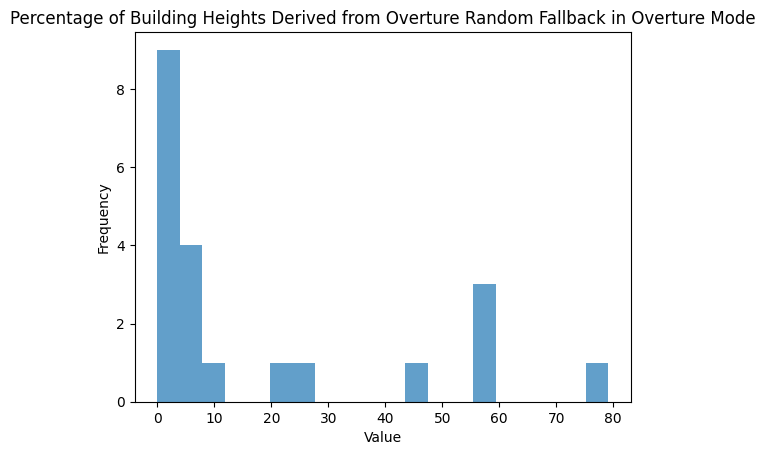

In [ ]:
print_and_plot_stats(overture_random_fallback_perc, "Percentage of Building Heights Derived from Overture Random Fallback in Overture Mode")

Mean of Mean Absolute Difference in Meters Btw Building Pixels: 8.12
Median of Mean Absolute Difference in Meters Btw Building Pixels: 7.31


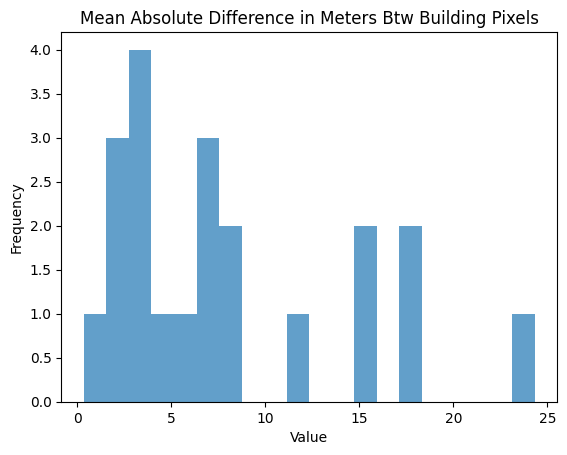

In [ ]:
print_and_plot_stats(overall_mean_abs_diff, "Mean Absolute Difference in Meters Btw Building Pixels")

Mean of Maximum Absolute Difference in Meters Btw Building Pixels: 44.81
Median of Maximum Absolute Difference in Meters Btw Building Pixels: 22.00


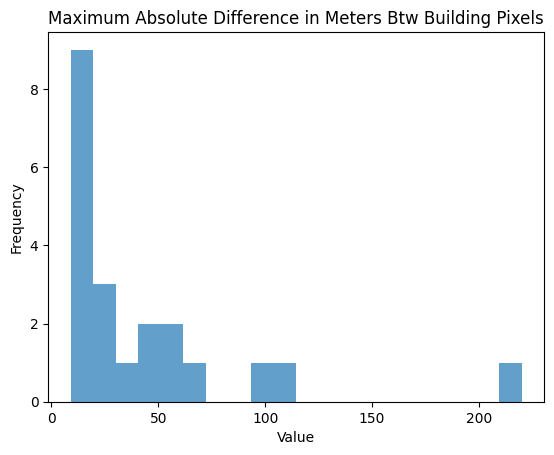

In [ ]:
print_and_plot_stats(overall_max_abs_diff, "Maximum Absolute Difference in Meters Btw Building Pixels")

Mean of Percentage of Building Pixels Found by LiDAR Not Found by Overture: 10.91
Median of Percentage of Building Pixels Found by LiDAR Not Found by Overture: 2.17


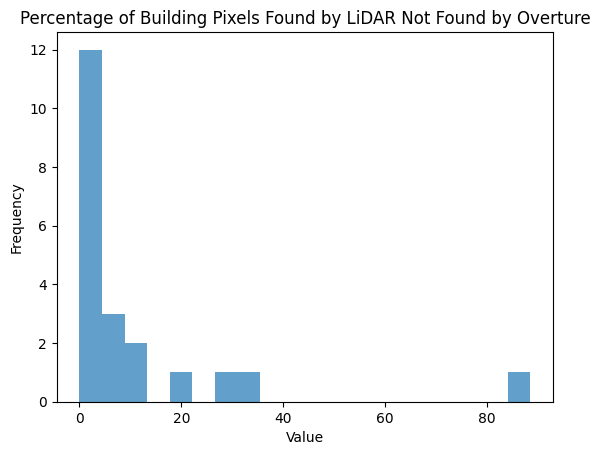

In [ ]:
print_and_plot_stats(lidar_outside_explicit_overture_height, "Percentage of Building Pixels Found by LiDAR Not Found by Overture")